# MLP Time-Series Forecasting with Optuna
This notebook mirrors the LSTM pipeline but uses a Multi-Layer Perceptron (MLP) on flattened time windows and searches the provided hyperparameter space.

In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

try:
    import optuna
except ImportError:
    optuna = None

import matplotlib.pyplot as plt
from copy import deepcopy

C:\Users\santo\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---- Config ----
DATA_PATH = "new_proj_data.csv"
TARGET_COL = "DiffTreasuryYield"
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
RANDOM_SEED = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Optuna search
N_TRIALS = 25
TIMEOUT = 1800  # seconds
EPOCHS_TUNE = 20
EPOCHS_FINAL = 30

CHECKPOINT_PATH = "mlp_diff_tuned.pt"

FORCE_RETRAIN = False

EARLY_STOP_PATIENCE = 5

In [3]:

def load_dataframe(path: str = DATA_PATH):
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")
    df.set_index("date", inplace=True)
    df[TARGET_COL] = df["TreasuryYield"] - df["TreasuryYield"].shift(-1)
    return df.dropna().copy()


def split_and_scale(df: pd.DataFrame):
    feature_cols = [c for c in df.columns if c != TARGET_COL]
    n = len(df)
    train_end = int(n * TRAIN_SPLIT)
    val_end = int(n * (TRAIN_SPLIT + VAL_SPLIT))

    def _split(mat):
        return mat[:train_end], mat[train_end:val_end], mat[val_end:]

    X = df[feature_cols].to_numpy()
    y = df[TARGET_COL].to_numpy().reshape(-1, 1)

    X_tr, X_va, X_te = _split(X)
    y_tr, y_va, y_te = _split(y)

    x_scaler = StandardScaler().fit(X_tr)
    y_scaler = StandardScaler().fit(y_tr)

    X_tr_s, X_va_s, X_te_s = [x_scaler.transform(m) for m in (X_tr, X_va, X_te)]
    y_tr_s, y_va_s, y_te_s = [y_scaler.transform(m) for m in (y_tr, y_va, y_te)]

    arrays = (X_tr_s, y_tr_s, X_va_s, y_va_s, X_te_s, y_te_s)
    split_idx = {"train_end": train_end, "val_end": val_end}
    return arrays, feature_cols, (x_scaler, y_scaler), split_idx


In [4]:
class WindowMLPDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, seq_len: int, hist: np.ndarray | None = None):
        hist = np.empty((0, X.shape[1]), dtype=X.dtype) if hist is None else hist
        self.src = np.concatenate([hist, X], axis=0)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.seq_len = seq_len
        self.hist_len = len(hist)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx: int):
        t = self.hist_len + idx
        window = self.src[t - self.seq_len : t]
        x_flat = window.reshape(-1)
        return torch.tensor(x_flat, dtype=torch.float32), self.y[idx]


def make_loaders(seq_len: int, batch_size: int, arrays, drop_last_train: bool = True):
    X_tr, y_tr, X_va, y_va, X_te, y_te = arrays
    train_ds = WindowMLPDataset(X_tr[seq_len:], y_tr[seq_len:], seq_len, hist=X_tr[:seq_len])
    val_ds = WindowMLPDataset(X_va, y_va, seq_len, hist=X_tr[-seq_len:])
    test_ds = WindowMLPDataset(X_te, y_te, seq_len, hist=X_va[-seq_len:])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=drop_last_train)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


In [5]:
def make_eval_loaders(seq_len: int, batch_size: int, arrays):
    X_tr, y_tr, X_va, y_va, X_te, y_te = arrays
    train_ds = WindowMLPDataset(X_tr[seq_len:], y_tr[seq_len:], seq_len, hist=X_tr[:seq_len])
    val_ds = WindowMLPDataset(X_va, y_va, seq_len, hist=X_tr[-seq_len:])
    test_ds = WindowMLPDataset(X_te, y_te, seq_len, hist=X_va[-seq_len:])

    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=False, drop_last=False),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False),
    )


In [6]:
ACTIVATIONS = {"relu": nn.ReLU(), "gelu": nn.GELU()}


def build_widths(hidden_base: int, n_layers: int, width_decay: float):
    widths = [hidden_base]
    for _ in range(1, n_layers):
        next_w = max(32, round(widths[-1] * width_decay))
        widths.append(next_w)
    return widths


class MLPRegressor(nn.Module):
    def __init__(self, input_dim: int, widths: list[int], activation: str, dropout: float, batch_norm: bool):
        super().__init__()
        layers: list[nn.Module] = []
        act = ACTIVATIONS[activation]
        for i, w in enumerate(widths):
            in_dim = input_dim if i == 0 else widths[i - 1]
            layers.append(nn.Linear(in_dim, w))
            if batch_norm:
                layers.append(nn.BatchNorm1d(w))
            layers.append(act)
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(widths[-1], 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


In [7]:
def make_loss(loss_name: str, huber_delta: float | None):
    if loss_name == "mse":
        return nn.MSELoss()
    if loss_name == "mae":
        return nn.L1Loss()
    if loss_name == "huber":
        return nn.HuberLoss(delta=huber_delta if huber_delta is not None else 1.0)
    raise ValueError(loss_name)


In [8]:
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module):
    model.eval()
    losses, preds, trues = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            yhat = model(xb)
            loss = criterion(yhat, yb.squeeze(-1) if yb.ndim > 1 else yb)
            losses.append(loss.item())
            preds.append(yhat.cpu().numpy())
            trues.append(yb.cpu().numpy())
    return float(np.mean(losses)), np.concatenate(preds), np.concatenate(trues)


def train_one_epoch(model, loader, criterion, optimizer, grad_clip: float | None):
    model.train()
    losses = []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        yhat = model(xb)
        loss = criterion(yhat, yb.squeeze(-1) if yb.ndim > 1 else yb)
        loss.backward()
        if grad_clip is not None:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


def rmse_mae_unscaled(yhat_s, ytrue_s, y_scaler):
    yhat = y_scaler.inverse_transform(yhat_s.reshape(-1, 1))
    ytrue = y_scaler.inverse_transform(ytrue_s.reshape(-1, 1))
    rmse = float(np.sqrt(mean_squared_error(ytrue, yhat)))
    mae = float(mean_absolute_error(ytrue, yhat))
    return rmse, mae


In [9]:

def persistence_baseline_scores(df, split_idx):
    train_end, val_end = split_idx["train_end"], split_idx["val_end"]
    y_true = df[TARGET_COL].to_numpy()
    y_pred = np.zeros_like(y_true)
    splits = {
        "train": (0, train_end),
        "val": (train_end, val_end),
        "test": (val_end, len(df)),
    }
    scores = {}
    for name, (s, e) in splits.items():
        rmse = float(np.sqrt(mean_squared_error(y_true[s:e], y_pred[s:e])))
        mae = float(mean_absolute_error(y_true[s:e], y_pred[s:e]))
        scores[name] = {"rmse": rmse, "mae": mae}
    return scores


def rebuild_arrays_with_scalers(df, feature_cols, x_scaler, y_scaler):
    n = len(df)
    train_end = int(n * TRAIN_SPLIT)
    val_end = int(n * (TRAIN_SPLIT + VAL_SPLIT))
    X = df[feature_cols].to_numpy()
    y = df[TARGET_COL].to_numpy().reshape(-1, 1)

    X_tr, X_va, X_te = X[:train_end], X[train_end:val_end], X[val_end:]
    y_tr, y_va, y_te = y[:train_end], y[train_end:val_end], y[val_end:]

    X_tr_s, X_va_s, X_te_s = [x_scaler.transform(m) for m in (X_tr, X_va, X_te)]
    y_tr_s, y_va_s, y_te_s = [y_scaler.transform(m) for m in (y_tr, y_va, y_te)]

    arrays = (X_tr_s, y_tr_s, X_va_s, y_va_s, X_te_s, y_te_s)
    split_idx = {"train_end": train_end, "val_end": val_end}
    return arrays, split_idx


def load_checkpoint_mlp(path: str | Path, device=DEVICE):
    allowed = [StandardScaler]
    load_kwargs = {"map_location": device}
    try:
        with torch.serialization.safe_globals(allowed):
            payload = torch.load(path, weights_only=False, **load_kwargs)
    except TypeError:
        # Torch <2.6 does not support weights_only
        with torch.serialization.safe_globals(allowed):
            payload = torch.load(path, **load_kwargs)

    cfg = payload["config"]
    best_params = payload.get("best_params", {})
    scalers = (payload["scalers"]["x"], payload["scalers"]["y"])
    widths = cfg["widths"]
    seq_len = cfg["seq_len"]
    batch_size = cfg.get("batch_size", 64)
    input_dim = cfg["n_features"] * seq_len
    activation = best_params.get("activation", "relu")
    dropout = best_params.get("dropout", 0.0)
    batch_norm = best_params.get("batch_norm", False)
    model = MLPRegressor(input_dim, widths, activation, dropout, batch_norm).to(device)
    model.load_state_dict(payload["state_dict"])
    model.eval()
    return model, best_params, scalers, seq_len, batch_size


def print_model_metrics(model, seq_len, batch_size, arrays, scalers, label="Model"):
    _, _, test_loader = make_eval_loaders(seq_len, batch_size, arrays)
    criterion = nn.MSELoss()
    _, p_s, t_s = evaluate(model, test_loader, criterion)
    rmse, mae = rmse_mae_unscaled(p_s, t_s, scalers[1])
    print(f"{label} | Test RMSE: {rmse:.4f} | MAE: {mae:.4f}")
    return rmse, mae


def plot_full_series(df, split_idx, seq_len, model, arrays, scalers, batch_size, title="Diff MLP vs Naive vs Actual"):
    train_end, val_end = split_idx["train_end"], split_idx["val_end"]
    train_loader, val_loader, test_loader = make_eval_loaders(seq_len, batch_size, arrays)

    preds_s, trues_s = [], []
    for loader in (train_loader, val_loader, test_loader):
        _, p_s, t_s = evaluate(model, loader, nn.MSELoss())
        preds_s.append(p_s)
        trues_s.append(t_s)

    y_scaler = scalers[1]
    preds = y_scaler.inverse_transform(np.concatenate(preds_s).reshape(-1, 1)).flatten()
    trues = y_scaler.inverse_transform(np.concatenate(trues_s).reshape(-1, 1)).flatten()

    idx_train = df.index[seq_len:train_end]
    idx_val = df.index[train_end:val_end]
    idx_test = df.index[val_end:]
    idx_all = np.concatenate([idx_train, idx_val, idx_test])

    naive_concat = np.zeros_like(idx_all, dtype=float)

    plt.figure(figsize=(12, 6))
    plt.plot(idx_all, trues, label="Actual diff", linewidth=2)
    plt.plot(idx_all, preds, label="MLP (tuned)", alpha=0.8)
    plt.plot(idx_all, naive_concat, label="Naive (zero)", alpha=0.8)
    plt.axvline(df.index[train_end - 1], color="gray", linestyle="--", label="Train/Val split")
    plt.axvline(df.index[val_end - 1], color="gray", linestyle=":", label="Val/Test split")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [10]:
def objective(trial: optuna.Trial, arrays, scalers, n_features: int):
    # Hyperparameters
    seq_len = trial.suggest_categorical("seq_len", [20, 30, 60, 90, 120])
    hidden_base = trial.suggest_categorical("hidden_base", [64, 128, 256, 512])
    width_decay = trial.suggest_categorical("width_decay", [0.4, 0.55, 0.7, 0.85])
    n_layers = trial.suggest_int("n_layers", 2, 3)

    widths = build_widths(hidden_base, n_layers, width_decay)
    if widths[-1] < 32:
        raise optuna.TrialPruned()

    dropout_min = 0.25 if (hidden_base >= 512 and n_layers >= 3) else 0.2
    dropout = trial.suggest_float("dropout", dropout_min, 0.50)
    activation = trial.suggest_categorical("activation", ["relu", "gelu"])
    batch_norm = trial.suggest_categorical("batch_norm", [True, False])

    loss_name = trial.suggest_categorical("loss", ["huber", "mae", "mse"])
    huber_delta = None
    if loss_name == "huber":
        huber_delta = trial.suggest_categorical("huber_delta", [0.25, 0.5, 1.0, 2.0, 4.0])

    lr = trial.suggest_float("learning_rate", 5e-5, 2e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 5e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    grad_clip = trial.suggest_categorical("gradient_clip", [0.5, 1.0, 2.0, 5.0])

    train_loader, val_loader, _ = make_loaders(seq_len, batch_size, arrays)
    input_dim = n_features * seq_len
    model = MLPRegressor(input_dim, widths, activation, dropout, batch_norm).to(DEVICE)
    criterion = make_loss(loss_name, huber_delta)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    for _ in range(EPOCHS_TUNE):
        train_one_epoch(model, train_loader, criterion, optimizer, grad_clip)

    _, p_s, t_s = evaluate(model, val_loader, criterion)
    y_scaler = scalers[1]
    val_rmse, val_mae = rmse_mae_unscaled(p_s, t_s, y_scaler)
    trial.set_user_attr("val_mae", val_mae)
    return val_rmse


In [11]:
def train_final(best_params: dict, arrays, feature_cols, scalers):
    seq_len = best_params["seq_len"]
    batch_size = best_params["batch_size"]
    widths = build_widths(best_params["hidden_base"], best_params["n_layers"], best_params["width_decay"])
    dropout_min = 0.25 if (best_params["hidden_base"] >= 512 and best_params["n_layers"] >= 3) else 0.2
    dropout = max(0.2, dropout_min, best_params["dropout"])

    train_loader, val_loader, test_loader = make_loaders(seq_len, batch_size, arrays)
    input_dim = len(feature_cols) * seq_len
    model = MLPRegressor(input_dim, widths, best_params["activation"], dropout, best_params["batch_norm"]).to(DEVICE)

    criterion = make_loss(best_params["loss"], best_params.get("huber_delta"))
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"]
    )

    best_state = None
    best_val = float("inf")
    patience_ctr = 0
    for epoch in range(EPOCHS_FINAL):
        train_one_epoch(model, train_loader, criterion, optimizer, best_params["gradient_clip"])
        val_loss, _, _ = evaluate(model, val_loader, criterion)

        if val_loss < best_val:
            best_val = val_loss
            patience_ctr = 0
            best_state = deepcopy(model.state_dict())
        else:
            patience_ctr += 1
            if patience_ctr >= EARLY_STOP_PATIENCE:
                print(f"Early stopping at epoch {epoch+1} | Best val: {best_val:.5f}")
                break

        if (epoch + 1) % 10 == 0:
            print(f"Final epoch {epoch+1:02d} | Val loss (scaled): {val_loss:.5f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    _, p_s, t_s = evaluate(model, test_loader, criterion)
    y_scaler = scalers[1]
    test_rmse, test_mae = rmse_mae_unscaled(p_s, t_s, y_scaler)
    print(f"Tuned MLP | Test RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f}")

    payload = {
        "state_dict": model.state_dict(),
        "config": {"n_features": len(feature_cols), "widths": widths, "seq_len": seq_len, "batch_size": batch_size},
        "scalers": {"x": scalers[0], "y": scalers[1]},
        "best_params": best_params,
    }
    torch.save(payload, CHECKPOINT_PATH)
    print(f"Saved tuned MLP to {CHECKPOINT_PATH}")
    return model, best_params


Loaded 14274 rows; features: 10; device: cpu
Loaded checkpoint from mlp_diff_tuned.pt
Naive baseline (zero):
  train: RMSE 0.0490 | MAE 0.0320
  val: RMSE 0.0333 | MAE 0.0231
  test: RMSE 0.0459 | MAE 0.0313
Tuned MLP | Test RMSE: 2.8300 | MAE: 2.5707


C:\Users\santo\miniconda3\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


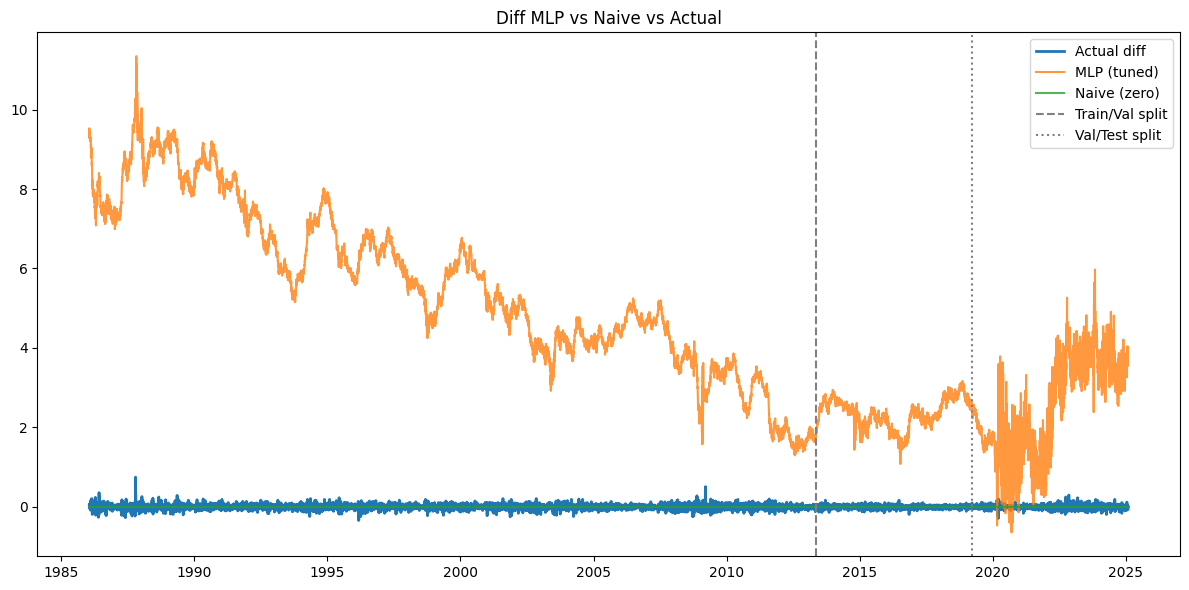

In [12]:
def main():
    if optuna is None:
        print("Optuna not installed; please pip install optuna")
        return
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    df = load_dataframe(DATA_PATH)
    arrays, feature_cols, scalers, split_idx = split_and_scale(df)
    print(f"Loaded {len(df)} rows; features: {len(feature_cols)}; device: {DEVICE}")

    model = None
    best_params = None
    seq_len = None
    batch_size = None

    if Path(CHECKPOINT_PATH).exists() and not FORCE_RETRAIN:
        model, best_params, scalers, seq_len, batch_size = load_checkpoint_mlp(CHECKPOINT_PATH, DEVICE)
        arrays, split_idx = rebuild_arrays_with_scalers(df, feature_cols, scalers[0], scalers[1])
        print(f"Loaded checkpoint from {CHECKPOINT_PATH}")
    else:
        study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
        study.optimize(lambda trial: objective(trial, arrays, scalers, len(feature_cols)), n_trials=N_TRIALS, timeout=TIMEOUT, show_progress_bar=True)

        best_params = study.best_trial.params
        print("Best trial:", study.best_trial.number)
        print("Val RMSE:", study.best_value)
        print("Val MAE attr:", study.best_trial.user_attrs.get("val_mae"))
        print("Params:", best_params)

        model, best_params = train_final(best_params, arrays, feature_cols, scalers)
        seq_len = best_params["seq_len"]
        batch_size = best_params["batch_size"]

    baseline = persistence_baseline_scores(df, split_idx)
    print("Naive baseline (zero):")
    for split, metrics in baseline.items():
        print(f"  {split}: RMSE {metrics['rmse']:.4f} | MAE {metrics['mae']:.4f}")

    print_model_metrics(model, seq_len, batch_size, arrays, scalers, label="Tuned MLP")
    plot_full_series(df, split_idx, seq_len, model, arrays, scalers, batch_size, title="Diff MLP vs Naive vs Actual")


if __name__ == "__main__":
    main()
